# 数据预处理

## 读取数据&查看数据基本信息

In [22]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('Z:/李玲珑_data/玲珑 at UCSD/20260306/coded_ideas_RA_semantic_精简.csv')

# 查看数据基本信息
print("数据形状:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n数据类型:")
print(df.dtypes)


数据形状: (343, 41)

前5行数据:
   synthetic_id  category_1  category_2  category_3  category_4  category_5  \
0             1         1.0         3.0         1.0         NaN         NaN   
1             2         NaN         NaN         NaN         NaN         NaN   
2             3         1.0         NaN         NaN         NaN         NaN   
3             4         NaN         NaN         NaN         NaN         NaN   
4             5         3.0         NaN         NaN         NaN         NaN   

   category_6  category_7  category_8  category_9  ...  category_31  \
0         NaN         NaN         NaN         NaN  ...          NaN   
1         NaN         NaN         NaN         NaN  ...          NaN   
2         NaN         NaN         NaN         NaN  ...          NaN   
3         NaN         NaN         NaN         NaN  ...          NaN   
4         NaN         NaN         NaN         NaN  ...          NaN   

   category_32  category_33  category_34  category_35  category_36  \
0   

## 分离两组数据

In [23]:
# 分离两组数据
group1 = df.iloc[:, 1:21]  # category_1 到 category_20
group2 = df.iloc[:, 21:41]  # category_21 到 category_40

print("第一组 (category_1-20):")
print(f"列数: {group1.shape[1]}")
print(f"非空值数量: {group1.notna().sum().sum()}")
print(f"类别分布:\n{group1.stack().value_counts().sort_index()}")

print("\n" + "="*50)
print("第二组 (category_21-40):")
print(f"列数: {group2.shape[1]}")
print(f"非空值数量: {group2.notna().sum().sum()}")
print(f"类别分布:\n{group2.stack().value_counts().sort_index()}")


第一组 (category_1-20):
列数: 20
非空值数量: 547
类别分布:
1.0    344
2.0     23
3.0    179
4.0      1
Name: count, dtype: int64

第二组 (category_21-40):
列数: 20
非空值数量: 600
类别分布:
1.0    314
2.0     33
3.0    231
4.0     22
Name: count, dtype: int64


## 清洗数据

In [24]:
## 用NaN代替每个cell中不是 1.0, 2.0, 3.0 的数据， 然后删除只有NaN数据的行

# 定义允许的值，因为值是 4.0 的源数据是乱填，无效回答，所以也清除
allowed_values = [1.0, 2.0, 3.0]

# --- 第一步：对所有列执行替换 ---
# 注意：非数字列（如字符串 'A'）因为不在 allowed_values 中，也会变成 NaN
group1 = group1.where(group1.isin(allowed_values), np.nan)
group2 = group2.where(group2.isin(allowed_values), np.nan)
                      
# --- 第二步：删除所有列全为 NaN 的行 ---

# how='all' 表示只有当一行中所有列都是 NaN 时才删除
group1 = group1.dropna(how='all').reset_index(drop=True)
group2 = group2.dropna(how='all').reset_index(drop=True)

## 保存数据

In [16]:
group1.to_csv('Z:/李玲珑_data/玲珑 at UCSD/20260306/group1.csv')
group2.to_csv('Z:/李玲珑_data/玲珑 at UCSD/20260306/group2.csv')

# 早期分析

## 分别统计1和3两个类别在每行出现的次数，以及按 非 NaN 数据 计算的频率

$$
\text{频率}=\frac{\text{1.0 或 3.0 的个数}}{\text{该行非 NaN 的个数}}
$$


统计得到并使用的频率计数如下：  
139, 20, 111, 1,    # 第一组频率计数  
138, 24, 117, 2,   # 第二组频率计数

In [25]:
## 计算 group1

# 每行非 NaN 数量
valid_n = group1.notna().sum(axis=1)

# 统计出现次数
count_1 = (group1 == 1.0).sum(axis=1)
count_3 = (group1 == 3.0).sum(axis=1)

# 计算频率（按非 NaN）
freq_1 = count_1 / valid_n
freq_3 = count_3 / valid_n

# 合并结果
result_1 = pd.DataFrame({
    "count_1": count_1,
    "freq_1": freq_1,
    "count_3": count_3,
    "freq_3": freq_3
})

# 显示结果
# result_1

## 计算 group2

# 每行非 NaN 数量
valid_n = group2.notna().sum(axis=1)

# 统计出现次数
count_1 = (group2 == 1.0).sum(axis=1)
count_3 = (group2 == 3.0).sum(axis=1)

# 计算频率（按非 NaN）
freq_1 = count_1 / valid_n
freq_3 = count_3 / valid_n

# 合并结果
result_2 = pd.DataFrame({
    "count_1": count_1,
    "freq_1": freq_1,
    "count_3": count_3,
    "freq_3": freq_3
})

# 显示结果
result_2
 

,count_1,freq_1,count_3,freq_3
0,1,0.333333,2,0.666667
1,2,0.666667,1,0.333333
2,2,0.666667,1,0.333333
3,2,0.666667,1,0.333333
4,2,1.000000,0,0.000000
...,...,...,...,...
164,3,0.600000,2,0.400000
165,4,0.800000,1,0.200000
166,3,0.750000,1,0.250000
167,0,0.000000,1,1.000000


## Mann-Whitney U 检验比较频率

研究问题是：比较每个人选择1.0的比例  

把每个人的 freq_1 或 freq_3 当作连续变量，因为不满足正态（推荐），用 Mann-Whitney U 检验。

In [27]:
from scipy.stats import mannwhitneyu


stat, p = mannwhitneyu(result_2['freq_1'], result_1['freq_1'], alternative='two-sided')

print(stat, p)

13108.5 0.1573123116682763


# chatgpt的方案

## 方案1

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf


Mann-Whitney test
freq_1: U=15947.000 p=0.14062
freq_3: U=13686.500 p=0.29621
Optimization terminated successfully.
         Current function value: 0.676553
         Iterations 4

Logistic regression
                           Logit Regression Results                           
Dep. Variable:                    is1   No. Observations:                 1147
Model:                          Logit   Df Residuals:                     1145
Method:                           MLE   Df Model:                            1
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                0.008354
Time:                        14:59:57   Log-Likelihood:                -776.01
converged:                       True   LL-Null:                       -782.54
Covariance Type:            nonrobust   LLR p-value:                 0.0002993
                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

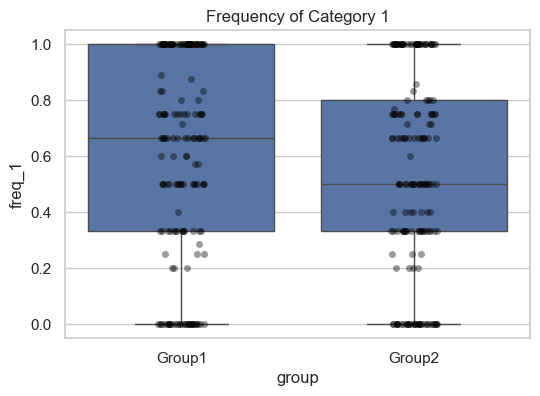

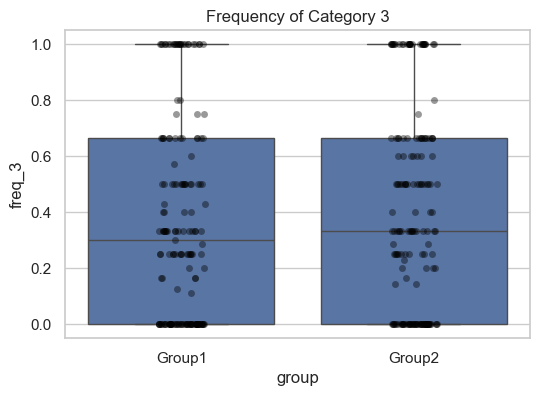


Descriptive statistics
response freq_1                                                        freq_3  \
          count      mean       std  min       25%       50%  75%  max  count   
group                                                                           
Group1    171.0  0.593509  0.367846  0.0  0.333333  0.666667  1.0  1.0  171.0   
Group2    171.0  0.539294  0.354925  0.0  0.333333  0.500000  0.8  1.0  171.0   

response                                                         
              mean       std  min  25%       50%       75%  max  
group                                                            
Group1    0.360821  0.355263  0.0  0.0  0.300000  0.666667  1.0  
Group2    0.399539  0.358403  0.0  0.0  0.333333  0.666667  1.0  


In [18]:
# =========================
# 1 读取数据
# =========================

g1 = group1.copy()
g2 = group2.copy()

g1["group"] = "Group1"
g2["group"] = "Group2"

df = pd.concat([g1, g2], ignore_index=True)
df["participant"] = np.arange(len(df))

# =========================
# 2 转换为 long format
# =========================

long = df.melt(
    id_vars=["participant","group"],
    var_name="question",
    value_name="response"
)

long = long.dropna()

# =========================
# 3 计算每人频率
# =========================

freq = (
    long.groupby(["participant","group"])["response"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reset_index()
)

freq = freq.rename(columns={
    1:"freq_1",
    3:"freq_3"
})

# =========================
# 4 Mann-Whitney U test
# =========================

g1_f1 = freq[freq.group=="Group1"]["freq_1"]
g2_f1 = freq[freq.group=="Group2"]["freq_1"]

g1_f3 = freq[freq.group=="Group1"]["freq_3"]
g2_f3 = freq[freq.group=="Group2"]["freq_3"]

u1,p1 = mannwhitneyu(g1_f1,g2_f1,alternative="two-sided")
u3,p3 = mannwhitneyu(g1_f3,g2_f3,alternative="two-sided")

print("\nMann-Whitney test")
print("freq_1: U=%.3f p=%.5f"%(u1,p1))
print("freq_3: U=%.3f p=%.5f"%(u3,p3))

# =========================
# 5 Logistic regression
# =========================

long["is1"] = (long["response"]==1).astype(int)

model = smf.logit("is1 ~ group", data=long).fit()

print("\nLogistic regression")
print(model.summary())

# Odds Ratio
odds_ratio = np.exp(model.params)
print("\nOdds Ratio")
print(odds_ratio)

# =========================
# 6 可视化
# =========================

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.boxplot(data=freq,x="group",y="freq_1")
sns.stripplot(data=freq,x="group",y="freq_1",color="black",alpha=0.4)
plt.title("Frequency of Category 1")
plt.savefig("freq1_boxplot.png",dpi=300)
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=freq,x="group",y="freq_3")
sns.stripplot(data=freq,x="group",y="freq_3",color="black",alpha=0.4)
plt.title("Frequency of Category 3")
plt.savefig("freq3_boxplot.png",dpi=300)
plt.show()

# =========================
# 7 描述统计
# =========================

desc = freq.groupby("group")[["freq_1","freq_3"]].describe()
print("\nDescriptive statistics")
print(desc)

## 方案2 

In [21]:
import pandas as pd
import numpy as np

from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

# ==============================
# 1 读取数据
# ==============================

# g1 = group1.copy()
# g2 = group2.copy()
g1 = pd.read_csv("Z:/李玲珑_data/玲珑 at UCSD/20260306/group1.csv")
g2 = pd.read_csv("Z:/李玲珑_data/玲珑 at UCSD/20260306/group2.csv")

g1["group"] = "Group1"
g2["group"] = "Group2"

df = pd.concat([g1, g2], ignore_index=True)

df["participant"] = np.arange(len(df))

print("Group sizes:")
print(df["group"].value_counts())

# ==============================
# 2 转换 long format
# ==============================

long = df.melt(
    id_vars=["participant", "group"],
    var_name="question",
    value_name="response"
)

long = long.dropna()

print("\nTotal valid responses:")
print(long.shape[0])

# ==============================
# 3 计算每人频率
# ==============================

freq = (
    long.groupby(["participant","group"])["response"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reset_index()
)

freq = freq.rename(columns={
    1: "freq_1",
    3: "freq_3"
})

print("\nFrequency table head:")
print(freq.head())

# ==============================
# 4 描述统计
# ==============================

desc = freq.groupby("group")[["freq_1","freq_3"]].describe()

print("\nDescriptive statistics")
print(desc)

# ==============================
# 5 Mann–Whitney U test
# ==============================

g1_f1 = freq[freq.group=="Group1"]["freq_1"]
g2_f1 = freq[freq.group=="Group2"]["freq_1"]

g1_f3 = freq[freq.group=="Group1"]["freq_3"]
g2_f3 = freq[freq.group=="Group2"]["freq_3"]

u1, p1 = mannwhitneyu(g1_f1, g2_f1, alternative="two-sided")
u3, p3 = mannwhitneyu(g1_f3, g2_f3, alternative="two-sided")

print("\nMann-Whitney U test")
print("freq_1: U =", u1, "p =", p1)
print("freq_3: U =", u3, "p =", p3)

# ==============================
# 6 logistic regression
# ==============================

long["is1"] = (long["response"] == 1).astype(int)

model = smf.logit("is1 ~ group", data=long).fit()

print("\nLogistic regression result")
print(model.summary())

# Odds ratio
odds_ratio = np.exp(model.params)

print("\nOdds Ratio")
print(odds_ratio)

# ==============================
# 7 整体类别分布
# ==============================

overall = long.groupby(["group","response"]).size().unstack(fill_value=0)

print("\nOverall category counts")
print(overall)

print("\nOverall category proportions")

prop = overall.div(overall.sum(axis=1), axis=0)

print(prop)

Group sizes:
group
Group1    171
Group2    171
Name: count, dtype: int64

Total valid responses:
1489

Frequency table head:
response  participant   group   0.0    freq_1   2.0    freq_3   4.0  5.0  6.0  \
0                   0  Group1  0.25  0.500000  0.00  0.250000  0.00  0.0  0.0   
1                   1  Group1  0.00  1.000000  0.00  0.000000  0.00  0.0  0.0   
2                   2  Group1  0.00  0.000000  0.50  0.500000  0.00  0.0  0.0   
3                   3  Group1  0.00  0.777778  0.00  0.222222  0.00  0.0  0.0   
4                   4  Group1  0.00  0.000000  0.25  0.500000  0.25  0.0  0.0   

response  7.0  ...  161.0  162.0  163.0  164.0  165.0  166.0  167.0  168.0  \
0         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
1         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
3         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  